In [1]:
import sys
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt

from data_loader import download_prices, compute_log_returns, compute_losses
from hill_estimator import hill_estimator

# télécharger et préparer les données
ticker = "^GSPC"
prices = download_prices(ticker, start="2004-01-01")
returns = compute_log_returns(prices)
losses = compute_losses(returns)

print(f"{len(losses)} jours de perte disponibles")

2592 jours de perte disponibles


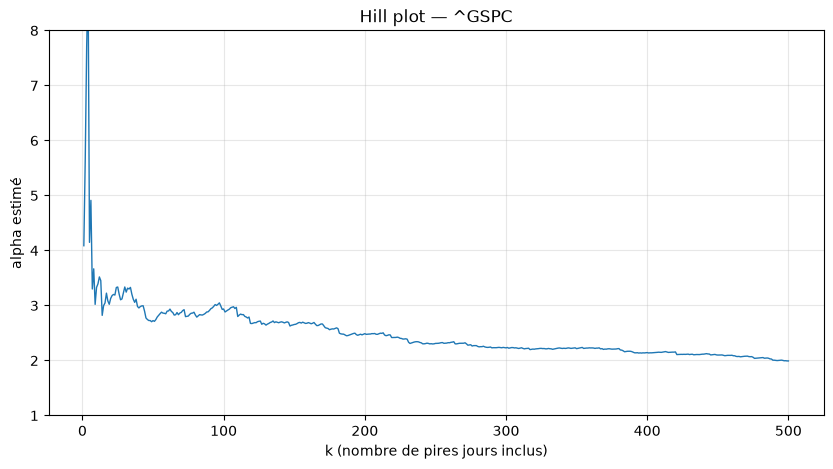

In [2]:
kmax = 500  # on a 2592 pertes, donc 500 c'est raisonnable (moins de 20% du total)

k_values, alpha_values = hill_estimator(losses.values, kmax=kmax)

plt.figure(figsize=(10, 5))
plt.plot(k_values, alpha_values, linewidth=1)
plt.xlabel("k (nombre de pires jours inclus)")
plt.ylabel("alpha estimé")
plt.title(f"Hill plot — {ticker}")
plt.grid(alpha=0.3)
plt.ylim(1, 8)  # zoom sur une plage raisonnable, ajuste si besoin
plt.show()

In [3]:
k_chosen = 200
alpha_final = alpha_values[k_chosen - 1]  # -1 car k_values commence à 1
print(f"Alpha final choisi (k={k_chosen}): {alpha_final:.2f}")

Alpha final choisi (k=200): 2.49


In [4]:
tickers = {
    "S&P 500": "^GSPC",
    "CAC 40": "^FCHI",
    "Nikkei 225": "^N225",
    "EuroStoxx 50": "^STOXX50E",
}

results = {}

for name, ticker in tickers.items():
    try:
        p = download_prices(ticker, start="2004-01-01")
        r = compute_log_returns(p)
        l = compute_losses(r)

        kmax = min(500, len(l) - 1)  # sécurité si un indice a moins de données
        k_vals, alphas = hill_estimator(l.values, kmax=kmax)

        results[name] = {
            "k_values": k_vals,
            "alpha_values": alphas,
            "n_losses": len(l),
        }
        print(f"{name}: {len(l)} jours de perte, OK")
    except Exception as e:
        print(f"{name}: erreur - {e}")

S&P 500: 2592 jours de perte, OK
CAC 40: 2777 jours de perte, OK
Nikkei 225: 2630 jours de perte, OK
EuroStoxx 50: 2346 jours de perte, OK


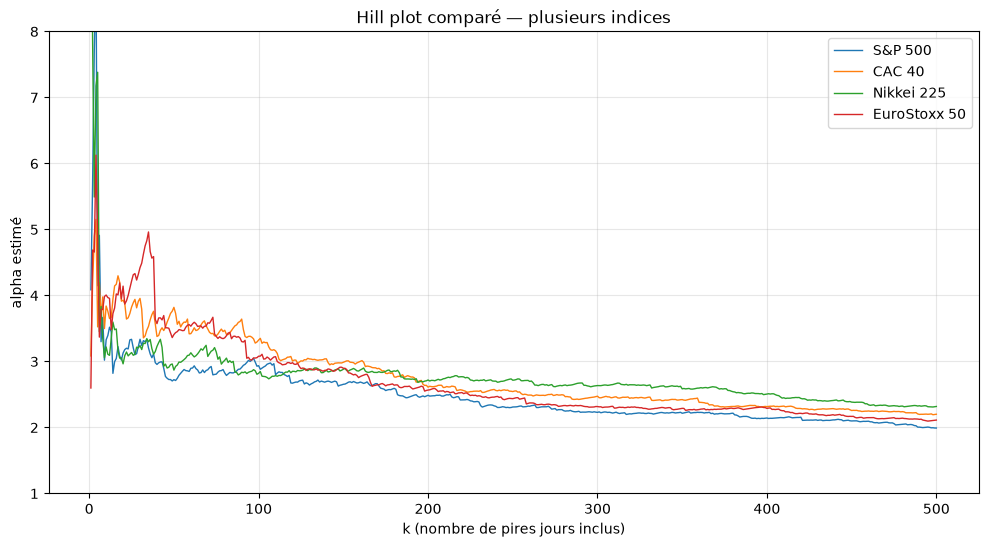

In [5]:
plt.figure(figsize=(12, 6))

for name, res in results.items():
    plt.plot(res["k_values"], res["alpha_values"], linewidth=1, label=name)

plt.xlabel("k (nombre de pires jours inclus)")
plt.ylabel("alpha estimé")
plt.title("Hill plot comparé — plusieurs indices")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(1, 8)
plt.show()

In [6]:
k_chosen = 200

print(f"Alpha final par indice (k={k_chosen}):\n")
for name, res in results.items():
    alpha_final = res["alpha_values"][k_chosen - 1]
    print(f"  {name}: {alpha_final:.2f}")

Alpha final par indice (k=200):

  S&P 500: 2.49
  CAC 40: 2.61
  Nikkei 225: 2.72
  EuroStoxx 50: 2.57


In [ ]:
## Interprétation

Les quatre indices convergent vers un exposant de queue α ≈ 2.5-2.7 dans la
zone de plateau (k=200-300), bien en dessous de la fourchette théorique de
3-5 habituellement citée pour les actions. Cela suggère une queue de
distribution particulièrement épaisse sur la période 2004-2026, probablement
tirée par l'inclusion de deux crises majeures (2008, Covid mars 2020).

La convergence entre marchés géographiquement distincts (US, France, Japon,
zone euro) suggère que ce phénomène est structurel plutôt que spécifique à
un marché.

In [7]:
import sys
sys.path.append("../src")
from var_backtest import gaussian_var, count_breaches

var_threshold = gaussian_var(returns, confidence=0.99, window=250)
breach_dates, breach_rate = count_breaches(returns, var_threshold)

print(f"Nombre de breaches : {len(breach_dates)}")
print(f"Premières dates : {breach_dates[:10].tolist()}")
print(f"Dernières dates : {breach_dates[-10:].tolist()}")

Nombre de breaches : 149
Premières dates : [Timestamp('2005-04-15 00:00:00'), Timestamp('2005-10-05 00:00:00'), Timestamp('2005-10-20 00:00:00'), Timestamp('2006-01-20 00:00:00'), Timestamp('2006-05-17 00:00:00'), Timestamp('2006-05-30 00:00:00'), Timestamp('2006-06-05 00:00:00'), Timestamp('2007-02-27 00:00:00'), Timestamp('2007-03-13 00:00:00'), Timestamp('2007-06-07 00:00:00')]
Dernières dates : [Timestamp('2024-08-05 00:00:00'), Timestamp('2024-09-03 00:00:00'), Timestamp('2024-10-31 00:00:00'), Timestamp('2024-12-18 00:00:00'), Timestamp('2025-03-10 00:00:00'), Timestamp('2025-04-03 00:00:00'), Timestamp('2025-04-04 00:00:00'), Timestamp('2025-04-10 00:00:00'), Timestamp('2025-10-10 00:00:00'), Timestamp('2026-06-05 00:00:00')]


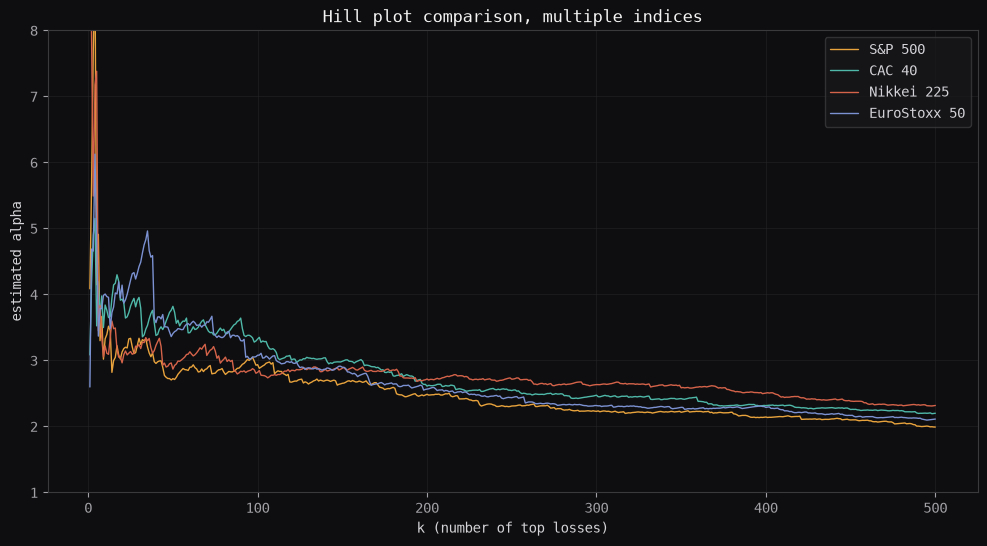

In [8]:
plt.style.use("../src/quant_dark.mplstyle")

# hill plot comparison across indices
plt.figure(figsize=(12, 6))
for name, res in results.items():
    plt.plot(res["k_values"], res["alpha_values"], linewidth=1, label=name)
plt.xlabel("k (number of top losses)")
plt.ylabel("estimated alpha")
plt.title("Hill plot comparison, multiple indices")
plt.legend()
plt.ylim(1, 8)
plt.savefig("../results/figures/hill_plot_comparison.png")
plt.show()

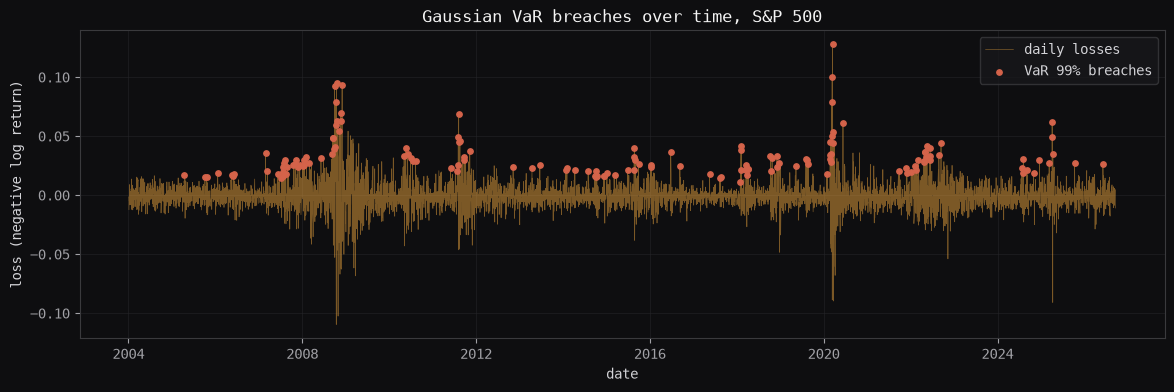

In [9]:
# VaR breach timeline
plt.figure(figsize=(14, 4))
plt.plot(returns.index, -returns, linewidth=0.5, alpha=0.5, label="daily losses")
plt.scatter(breach_dates, -returns.loc[breach_dates], color="#d4634a", s=15, zorder=5, label="VaR 99% breaches")
plt.xlabel("date")
plt.ylabel("loss (negative log return)")
plt.title("Gaussian VaR breaches over time, S&P 500")
plt.legend()
plt.savefig("../results/figures/var_breaches_timeline.png")
plt.show()